# LSTM-GCN with Static Graph

This notebook implements an LSTM-GCN model with a **static precomputed adjacency matrix**.

**Key features:**
- Uses fixed hyperparameters (no keras-tuner)
- Multiple model architecture versions
- Multiple graph options
- Clean, simple training pipeline

**Model Version Comparison:**
| Version | Residual | Final GCN Output | TimeDistributed | Notes |
|---------|----------|------------------|-----------------|-------|
| `v2` | Yes | 16 dims → Dense(1) | Nested | Original implementation |
| `v3` | No | 1 dim | Single | Paper-faithful (Section 5.1) |

**Graph Type Comparison:**
| Type | Data Source | Look-ahead Bias | Normalization |
|------|-------------|-----------------|---------------|
| `cvx` | Equity prices | Yes (full timeline) | None |
| `pearson` | Equity prices | Yes (full timeline) | None |
| `straddle_pearson` | Straddle returns | Configurable | Configurable |
| `equity_pearson` | Equity log returns | Configurable | Configurable |

**Output:** Performance metrics matching run_all_strategies.ipynb format

## 1. Setup

In [1]:
!pip install -q tensorflow>=2.16.0 keras-tuner empyrical-reloaded spektral

In [2]:
import os
import sys

# Clone repo (Colab) or use local path
if 'google.colab' in str(get_ipython()):
    if not os.path.exists('/content/repo'):
        !git clone https://github.com/adam-909/4yp.git /content/repo
    else:
        !cd /content/repo && git pull
    os.chdir('/content/repo/4YP-main')
else:
    os.chdir('/home/adam/new4YP/4YP-main')

sys.path.insert(0, os.getcwd())
print(f"Working directory: {os.getcwd()}")

Already up to date.
Working directory: /content/repo/4YP-main


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from empyrical import (
    sharpe_ratio,
    sortino_ratio,
    max_drawdown,
    annual_return,
    annual_volatility,
    calmar_ratio,
)

# Set random seeds for reproducibility
import random
random.seed(40)
np.random.seed(40)

import tensorflow as tf
tf.random.set_seed(40)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


## 2. Configuration

In [4]:
# Training/Test Configuration
TRAIN_START = 2011
TEST_START = 2017
TEST_END = 2023
TEST_WINDOW_SIZE = 6  # years

VOL_TARGET = 0.15  # 15% volatility target for normalization

# Model Architecture Version
# Options:
#   "v2" - Original implementation (residual connection, GCN outputs 16 dims, nested TimeDistributed)
#   "v3" - Paper-faithful (no residual, final GCN outputs 1 dim, single TimeDistributed)
MODEL_VERSION = "v2"

# Graph Configuration
# Options:
#   "cvx"             - Precomputed CVX optimization (uses full data - has look-ahead bias)
#   "pearson"         - Precomputed equity Pearson (uses full data - has look-ahead bias)
#   "straddle_pearson"- Compute on-the-fly from straddle returns (training data only)
#   "equity_pearson"  - Compute on-the-fly from equity log returns (training data only)
GRAPH_TYPE = "equity_pearson"
ALPHA = 100  # CVX optimization parameter (if using cvx)
BETA = 0.1   # CVX optimization parameter (if using cvx)
TAU = 0.5   # Correlation threshold (if using pearson, straddle_pearson, or equity_pearson)

# On-the-fly Pearson Configuration (only used if GRAPH_TYPE = "straddle_pearson" or "equity_pearson")
USE_TRAINING_DATA_ONLY = True  # If True, compute correlation only from training period (no look-ahead)
NORMALIZE_ADJACENCY = True     # If True, apply symmetric normalization like rolling implementation

# Model Configuration
TOTAL_TIME_STEPS = 20
TRAIN_VALID_RATIO = 0.6
NUM_EPOCHS = 300
EARLY_STOPPING_PATIENCE = 25

# Hyperparameters (fixed, no tuning)
HIDDEN_LAYER_SIZE = 10
DROPOUT_RATE = 0.4
LEARNING_RATE = 0.001
MAX_GRADIENT_NORM = 0.01
GCN_UNITS = 16  # Only used in v2; v3 uses this for intermediate layers, final layer outputs 1
NUM_GCN_LAYERS = 2
BATCH_SIZE = 32

print(f"Train: {TRAIN_START}-{TEST_START}")
print(f"Test:  {TEST_START}-{TEST_END}")
print(f"\nModel Version: {MODEL_VERSION}")
if MODEL_VERSION == "v2":
    print("  - Residual connection: Yes")
    print("  - GCN output dim: 16 (then Dense reduces to 1)")
    print("  - TimeDistributed: Nested")
elif MODEL_VERSION == "v3":
    print("  - Residual connection: No")
    print("  - GCN output dim: 1 (paper-faithful)")
    print("  - TimeDistributed: Single")
print(f"\nGraph Configuration:")
print(f"  Type: {GRAPH_TYPE}")
if GRAPH_TYPE == "cvx":
    print(f"  Alpha: {ALPHA}, Beta: {BETA}")
elif GRAPH_TYPE == "pearson":
    print(f"  Threshold (precomputed equity): {TAU}")
    print(f"  WARNING: Uses full data range - has look-ahead bias!")
elif GRAPH_TYPE == "straddle_pearson":
    print(f"  Threshold (straddle returns): {TAU}")
    print(f"  Use training data only: {USE_TRAINING_DATA_ONLY}")
    print(f"  Normalize adjacency: {NORMALIZE_ADJACENCY}")
elif GRAPH_TYPE == "equity_pearson":
    print(f"  Threshold (equity log returns): {TAU}")
    print(f"  Use training data only: {USE_TRAINING_DATA_ONLY}")
    print(f"  Normalize adjacency: {NORMALIZE_ADJACENCY}")

Train: 2011-2017
Test:  2017-2023

Model Version: v2
  - Residual connection: Yes
  - GCN output dim: 16 (then Dense reduces to 1)
  - TimeDistributed: Nested

Graph Configuration:
  Type: equity_pearson
  Threshold (equity log returns): 0.5
  Use training data only: True
  Normalize adjacency: True


## 3. Helper Functions

In [5]:
def load_captured_returns(results_path):
    """Load captured returns from CSV file."""
    df = pd.read_csv(results_path)
    df['time'] = pd.to_datetime(df['time'])
    return df


def calc_daily_returns(df, returns_col='captured_returns'):
    """Aggregate daily returns across all tickers."""
    num_tickers = df['identifier'].nunique()
    daily_ret = df.groupby('time')[returns_col].sum() / num_tickers
    daily_ret.index = pd.to_datetime(daily_ret.index)
    return daily_ret.sort_index()


def calc_vol_scaled_returns(daily_returns, target_vol=0.15):
    """Scale returns to target annualized volatility."""
    current_vol = daily_returns.std() * np.sqrt(252)
    if current_vol > 0:
        scale_factor = target_vol / current_vol
        return daily_returns * scale_factor
    return daily_returns


def calc_metrics(daily_returns, name="Strategy"):
    """Calculate all performance metrics."""
    metrics = {
        'Strategy': name,
        'E[Ret.]': annual_return(daily_returns),
        'Vol.': annual_volatility(daily_returns),
        'Sharpe': sharpe_ratio(daily_returns),
        'Sortino': sortino_ratio(daily_returns),
        'Max DD': -max_drawdown(daily_returns),
        'Calmar': calmar_ratio(daily_returns),
        'Hit Rate': (daily_returns > 0).mean(),
        'Avg P/L': daily_returns[daily_returns > 0].mean() / abs(daily_returns[daily_returns < 0].mean()) if (daily_returns < 0).any() else np.nan,
    }
    return metrics


def calc_metrics_vol_normalized(daily_returns, name="Strategy", target_vol=0.15):
    """Calculate metrics with volatility-normalized returns."""
    scaled_returns = calc_vol_scaled_returns(daily_returns, target_vol)
    metrics = calc_metrics(scaled_returns, name + " (Vol-Norm)")
    return metrics, scaled_returns


def display_metrics(metrics_dict):
    """Display metrics in a formatted table."""
    df = pd.DataFrame([metrics_dict])
    df = df.set_index('Strategy')
    
    # Format percentages
    for col in ['E[Ret.]', 'Vol.', 'Max DD', 'Hit Rate']:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: f"{x:.2%}")
    
    # Format ratios
    for col in ['Sharpe', 'Sortino', 'Calmar', 'Avg P/L']:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: f"{x:.3f}")
    
    display(df)
    return df


def calc_yearly_sharpes(daily_returns):
    """Calculate Sharpe ratio by year."""
    yearly = {}
    for year in sorted(daily_returns.index.year.unique()):
        yr_ret = daily_returns[daily_returns.index.year == year]
        yearly[year] = sharpe_ratio(yr_ret)
    return yearly


def plot_results(daily_returns_dict, title="Strategy Comparison"):
    """Plot cumulative returns, drawdown, and rolling Sharpe."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(daily_returns_dict)))
    
    # 1. Cumulative Returns
    ax1 = axes[0, 0]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        cum_ret = (1 + returns).cumprod() - 1
        ax1.plot(cum_ret.index, cum_ret.values, label=name, linewidth=1.5, color=color)
    ax1.set_title('Cumulative Returns')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Cumulative Return')
    ax1.legend(loc='upper left', fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # 2. Drawdown
    ax2 = axes[0, 1]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        cum = (1 + returns).cumprod()
        running_max = cum.cummax()
        drawdown = (cum - running_max) / running_max
        ax2.fill_between(drawdown.index, drawdown.values, 0, alpha=0.3, label=name, color=color)
    ax2.set_title('Drawdown')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Drawdown')
    ax2.legend(loc='lower left', fontsize=8)
    ax2.grid(True, alpha=0.3)
    
    # 3. Rolling 252-day Sharpe
    ax3 = axes[1, 0]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        rolling_sharpe = returns.rolling(252).mean() / returns.rolling(252).std() * np.sqrt(252)
        ax3.plot(rolling_sharpe.index, rolling_sharpe.values, label=name, linewidth=1, color=color)
    ax3.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax3.set_title('Rolling 252-Day Sharpe Ratio')
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Sharpe Ratio')
    ax3.legend(loc='upper left', fontsize=8)
    ax3.grid(True, alpha=0.3)
    
    # 4. Yearly Sharpe Comparison
    ax4 = axes[1, 1]
    yearly_data = {}
    for name, returns in daily_returns_dict.items():
        yearly_data[name] = calc_yearly_sharpes(returns)
    
    yearly_df = pd.DataFrame(yearly_data)
    yearly_df.plot(kind='bar', ax=ax4, width=0.8)
    ax4.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax4.set_title('Yearly Sharpe Ratios')
    ax4.set_xlabel('Year')
    ax4.set_ylabel('Sharpe Ratio')
    ax4.legend(loc='upper right', fontsize=8)
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 4. Data Loading and Preparation

In [6]:
# Load feature data
features_path = "/content/drive/MyDrive/features.csv"
df = pd.read_csv(features_path)
df['date'] = pd.to_datetime(df['date'])

print(f"Loaded {len(df)} rows")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Tickers: {df['ticker'].nunique()}")
print(f"\nColumns: {df.columns.tolist()}")

Loaded 274384 rows
Date range: 2010-07-01 00:00:00 to 2023-08-30 00:00:00
Tickers: 88

Columns: ['Date', 'straddle_price', 'exdate', 'moneyness', 'daily_returns', 'daily_vol', 'target_returns', 'norm_daily_return', 'norm_monthly_return', 'norm_quarterly_return', 'norm_biannual_return', 'norm_annual_return', 'macd_2_8', 'macd_4_16', 'macd_8_32', 'day_of_week', 'day_of_month', 'month_of_year', 'year', 'log_moneyness', 'time_to_expiry', 'ticker', 'date']


In [7]:
# Import the graph model features class
from gml.graph_model_inputs import GraphModelFeatures

# Create the feature generator
features = GraphModelFeatures(
    df=df,
    total_time_steps=TOTAL_TIME_STEPS,
    start_boundary=TRAIN_START,
    test_boundary=TEST_START,
    test_end=TEST_END,
    train_valid_ratio=TRAIN_VALID_RATIO,
    split_tickers_individually=True,
    time_features=False,
)

print("Feature generator created.")

no lags


train _batch
After final stacking and culling:
inputs.shape: (43, 88, 20, 10)
outputs.shape: (43, 88, 20, 1)
active_entries.shape: (43, 88, 20, 1)
identifier.shape: (43, 88, 20, 1)
date.shape: (43, 88, 20, 1)


valid _batch
After final stacking and culling:
inputs.shape: (28, 88, 20, 10)
outputs.shape: (28, 88, 20, 1)
active_entries.shape: (28, 88, 20, 1)
identifier.shape: (28, 88, 20, 1)
date.shape: (28, 88, 20, 1)


test _batch
After final stacking and culling:
inputs.shape: (70, 88, 20, 10)
outputs.shape: (70, 88, 20, 1)
active_entries.shape: (70, 88, 20, 1)
identifier.shape: (70, 88, 20, 1)
date.shape: (70, 88, 20, 1)


test sliding _batch
After final stacking and culling:
inputs.shape: (1400, 88, 20, 10)
outputs.shape: (1400, 88, 20, 1)
active_entries.shape: (1400, 88, 20, 1)
identifier.shape: (1400, 88, 20, 1)
date.shape: (1400, 88, 20, 1)
Feature generator created.


In [ ]:
# Get train/valid/test datasets
train_data = features.train
valid_data = features.valid
test_data = features.test_sliding

print("\nTraining data:")
print(f"  inputs: {train_data['inputs'].shape}")
print(f"  outputs: {train_data['outputs'].shape}")

print("\nValidation data:")
print(f"  inputs: {valid_data['inputs'].shape}")
print(f"  outputs: {valid_data['outputs'].shape}")

print("\nTest data:")
print(f"  inputs: {test_data['inputs'].shape}")
print(f"  outputs: {test_data['outputs'].shape}")


Training data:
  inputs: (43, 88, 20, 10)
  outputs: (43, 88, 20, 1)

Validation data:
  inputs: (28, 88, 20, 10)
  outputs: (28, 88, 20, 1)

Test data:
  inputs: (1400, 88, 20, 10)
  outputs: (1400, 88, 20, 1)


## 5. Load Adjacency Matrix

In [9]:
from gml.straddle_graph import load_or_compute_adjacency
from settings.default import ALL_TICKERS

# Load or compute the adjacency matrix based on GRAPH_TYPE
# Note: equity_pearson doesn't need df (uses cached equity returns)
adjacency = load_or_compute_adjacency(
    graph_type=GRAPH_TYPE,
    df=df if GRAPH_TYPE == "straddle_pearson" else None,
    alpha=ALPHA,
    beta=BETA,
    tau=TAU,
    tickers=ALL_TICKERS,
    train_end_year=TEST_START if (GRAPH_TYPE in ["straddle_pearson", "equity_pearson"] and USE_TRAINING_DATA_ONLY) else None,
    normalize=NORMALIZE_ADJACENCY if GRAPH_TYPE in ["straddle_pearson", "equity_pearson"] else False,
)

print(f"\nAdjacency matrix shape: {adjacency.shape}")
print(f"Non-zero entries: {(adjacency != 0).sum()}")
print(f"Value range: [{adjacency.min():.4f}, {adjacency.max():.4f}]")

Loading equity returns from cache: data/graph_structure/equity_returns/log_returns.csv
Using data before 2017 for correlation computation
Computing correlation from 2013 days of equity log returns
Date range: 2009-01-05 to 2016-12-30
Edges (before normalization): 660
Density: 0.1705
Applied symmetric normalization

Adjacency matrix shape: (88, 88)
Non-zero entries: 1408
Value range: [0.0000, 1.0000]


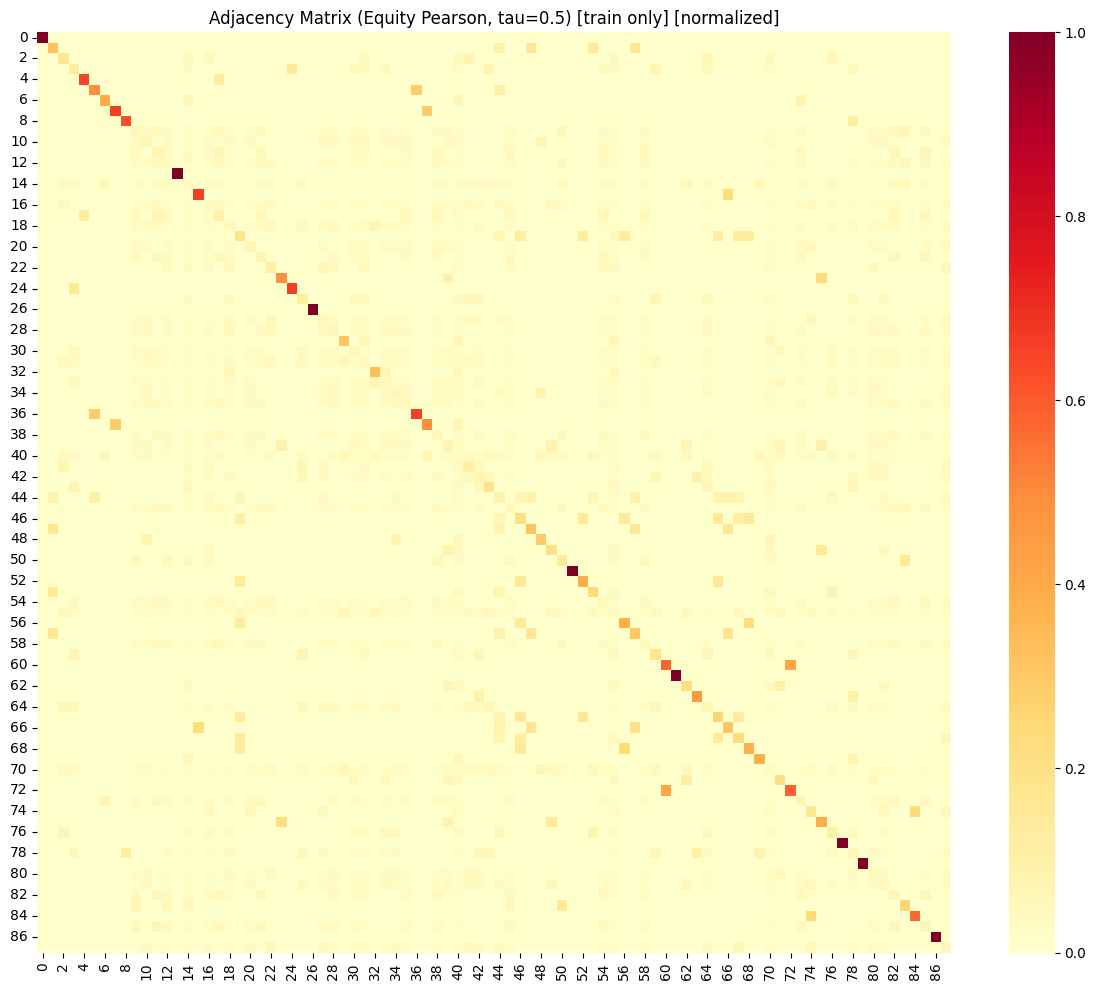

In [10]:
# Visualize adjacency matrix
plt.figure(figsize=(12, 10))
sns.heatmap(adjacency, cmap='YlOrRd')
if GRAPH_TYPE == "straddle_pearson":
    title = f"Adjacency Matrix (Straddle Pearson, tau={TAU})"
    if USE_TRAINING_DATA_ONLY:
        title += " [train only]"
    if NORMALIZE_ADJACENCY:
        title += " [normalized]"
elif GRAPH_TYPE == "equity_pearson":
    title = f"Adjacency Matrix (Equity Pearson, tau={TAU})"
    if USE_TRAINING_DATA_ONLY:
        title += " [train only]"
    if NORMALIZE_ADJACENCY:
        title += " [normalized]"
else:
    title = f"Adjacency Matrix ({GRAPH_TYPE.upper()})"
plt.title(title)
plt.tight_layout()
plt.show()

In [11]:
# Export adjacency graph to Gephi format
import networkx as nx
from settings.default import ALL_TICKERS, BBG_SECTORS

# Build graph with attributes
G = nx.Graph()
for i, ticker in enumerate(ALL_TICKERS):
    G.add_node(ticker,
                label=ticker,
                sector=BBG_SECTORS.get(ticker, "Unknown"))

for i in range(len(ALL_TICKERS)):
    for j in range(i + 1, len(ALL_TICKERS)):
        weight = adjacency[i, j]
        if weight > 0:
            G.add_edge(ALL_TICKERS[i], ALL_TICKERS[j], weight=float(weight))

# Export to GEXF
nx.write_gexf(G, "adjacency_graph.gexf")
print(f"Exported {G.number_of_nodes()} nodes, {G.number_of_edges()} edges to adjacency_graph.gexf")

Exported 88 nodes, 660 edges to adjacency_graph.gexf


## 6. Model Definition

In [12]:
# Import model based on MODEL_VERSION
if MODEL_VERSION == "v2":
    from gml.graph_model_2_v2 import build_lstm_gcn_model
    print("Using model v2 (original implementation)")
elif MODEL_VERSION == "v3":
    from gml.graph_model_2_v3 import build_lstm_gcn_model
    print("Using model v3 (paper-faithful)")
else:
    raise ValueError(f"Unknown MODEL_VERSION: {MODEL_VERSION}. Use 'v2' or 'v3'.")

# Get dimensions from data
num_tickers = train_data['inputs'].shape[1]
time_steps = train_data['inputs'].shape[2]
input_size = train_data['inputs'].shape[3]

print(f"\nBuilding model with:")
print(f"  num_tickers: {num_tickers}")
print(f"  time_steps: {time_steps}")
print(f"  input_size: {input_size}")

model = build_lstm_gcn_model(
    num_tickers=num_tickers,
    time_steps=time_steps,
    input_size=input_size,
    adjacency=adjacency,
    hidden_layer_size=HIDDEN_LAYER_SIZE,
    gcn_units=GCN_UNITS,
    dropout_rate=DROPOUT_RATE,
    learning_rate=LEARNING_RATE,
    max_gradient_norm=MAX_GRADIENT_NORM,
    num_gcn_layers=NUM_GCN_LAYERS,
)

# model.summary()

Using model v2 (original implementation)

Building model with:
  num_tickers: 88
  time_steps: 20
  input_size: 10


## 7. Training

In [ ]:
# Prepare training data
X_train = train_data['inputs']
y_train = train_data['outputs']
w_train = train_data['active_entries']

X_valid = valid_data['inputs']
y_valid = valid_data['outputs']
w_valid = valid_data['active_entries']

print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_valid.shape[0]}")

Training samples: 43
Validation samples: 28


In [14]:
# Training callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=EARLY_STOPPING_PATIENCE,
    restore_best_weights=True,
    verbose=1
)

# Train the model
print("="*60)
print(f"Training LSTM-GCN with Static Graph (Model {MODEL_VERSION})")
print(f"  Graph type: {GRAPH_TYPE}")
if GRAPH_TYPE == "cvx":
    print(f"  Alpha: {ALPHA}, Beta: {BETA}")
else:
    print(f"  Threshold: {TAU}")
print("="*60)

history = model.fit(
    X_train,
    y_train,
    sample_weight=w_train,
    validation_data=(X_valid, y_valid, w_valid),
    epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1,
)

Training LSTM-GCN with Static Graph (Model v2)
  Graph type: equity_pearson
  Threshold: 0.5
Epoch 1/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 280s 63s/step - loss: -0.4901 - val_loss: -0.3013
Epoch 2/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 611ms/step - loss: -0.5164 - val_loss: -0.3737
Epoch 3/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 602ms/step - loss: -0.6235 - val_loss: -0.4281
Epoch 4/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 630ms/step - loss: -0.6746 - val_loss: -0.4683
Epoch 5/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 618ms/step - loss: -0.6915 - val_loss: -0.4985
Epoch 6/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 626ms/step - loss: -0.7647 - val_loss: -0.5223
Epoch 7/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 624ms/step - loss: -0.7669 - val_loss: -0.5403
Epoch 8/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 920ms/step - loss: -0.7760 - val_loss: -0.5541
Epoch 9/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 848ms/step - loss: -0.7839 - val_loss: -0.5662
Epoch 10/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 818ms/step - loss: -0.8473 - val_loss: -0.5748
Epoch 11/300
2/2 ━━━━━━━━━━━━━━━━━━━

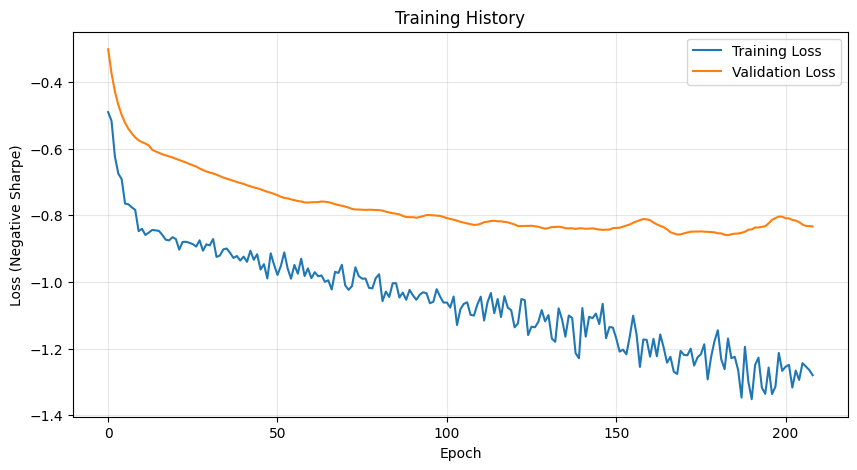

In [15]:
# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (Negative Sharpe)')
plt.title('Training History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. Evaluation

In [16]:
# Generate predictions on test set
X_test = test_data['inputs']
predictions = model.predict(X_test)

print(f"Predictions shape: {predictions.shape}")
print(f"Test outputs shape: {test_data['outputs'].shape}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step 
Predictions shape: (1400, 88, 20, 1)
Test outputs shape: (1400, 88, 20, 1)


In [17]:
# Calculate captured returns (using last time step for sliding window)
# For sliding windows, extract the final time step
positions = predictions[:, :, -1, 0].reshape(-1)
returns = test_data['outputs'][:, :, -1, 0].reshape(-1)
captured_returns = positions * returns

# Get dates and identifiers
dates = test_data['date'][:, :, -1, 0].reshape(-1)
identifiers = test_data['identifier'][:, :, -1, 0].reshape(-1)

# Create results dataframe
results_df = pd.DataFrame({
    'time': dates,
    'identifier': identifiers,
    'position': positions,
    'returns': returns,
    'captured_returns': captured_returns,
})

results_df['time'] = pd.to_datetime(results_df['time'])
results_df = results_df[results_df['identifier'] != '0']  # Remove padding

print(f"Results: {len(results_df)} rows")
results_df.head()

Results: 123200 rows


,time,identifier,position,returns,captured_returns
0,2017-01-03,AAPL,-0.131559,-0.009874,0.001299
1,2017-01-03,ABT,-0.072165,-0.002442,0.000176
2,2017-01-03,ACN,-0.113706,-0.008236,0.000937
3,2017-01-03,ADBE,-0.038264,-0.010764,0.000412
4,2017-01-03,AIG,-0.010822,-0.003832,0.000041


In [18]:
# Calculate daily returns
daily_returns = calc_daily_returns(results_df)

# Raw metrics
print("\n" + "="*60)
print(f"LSTM-GCN Static Graph Results (Raw)")
print(f"  Graph type: {GRAPH_TYPE}")
if GRAPH_TYPE == "cvx":
    print(f"  Alpha: {ALPHA}, Beta: {BETA}")
elif GRAPH_TYPE == "pearson":
    print(f"  Threshold (equity-based): {TAU}")
elif GRAPH_TYPE == "straddle_pearson":
    print(f"  Threshold (straddle-based): {TAU}")
    print(f"  Training data only: {USE_TRAINING_DATA_ONLY}")
    print(f"  Normalized: {NORMALIZE_ADJACENCY}")
elif GRAPH_TYPE == "equity_pearson":
    print(f"  Threshold (equity log returns): {TAU}")
    print(f"  Training data only: {USE_TRAINING_DATA_ONLY}")
    print(f"  Normalized: {NORMALIZE_ADJACENCY}")
print("="*60)

metrics_raw = calc_metrics(daily_returns, "LSTM-GCN Static")
display_metrics(metrics_raw)

# Vol-normalized metrics
print(f"\nVolatility-Normalized (Target: {VOL_TARGET:.0%})")
metrics_norm, scaled_returns = calc_metrics_vol_normalized(daily_returns, "LSTM-GCN Static", VOL_TARGET)
display_metrics(metrics_norm)

# Yearly Sharpes
print("\nYearly Sharpe Ratios:")
yearly_sharpes = calc_yearly_sharpes(daily_returns)
for year, sharpe in yearly_sharpes.items():
    print(f"  {year}: {sharpe:.4f}")


LSTM-GCN Static Graph Results (Raw)
  Graph type: equity_pearson
  Threshold (equity log returns): 0.5
  Training data only: True
  Normalized: True


,E[Ret.],Vol.,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Avg P/L
Strategy,,,,,,,,
LSTM-GCN Static,1.48%,1.86%,0.800,1.140,2.79%,0.532,58.29%,0.880



Volatility-Normalized (Target: 15%)


,E[Ret.],Vol.,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Avg P/L
Strategy,,,,,,,,
LSTM-GCN Static (Vol-Norm),11.48%,15.00%,0.800,1.140,21.60%,0.532,58.29%,0.880



Yearly Sharpe Ratios:
  2017: 2.4865
  2018: 0.3608
  2019: 2.4164
  2020: -0.0385
  2021: 1.3625
  2022: 1.2805


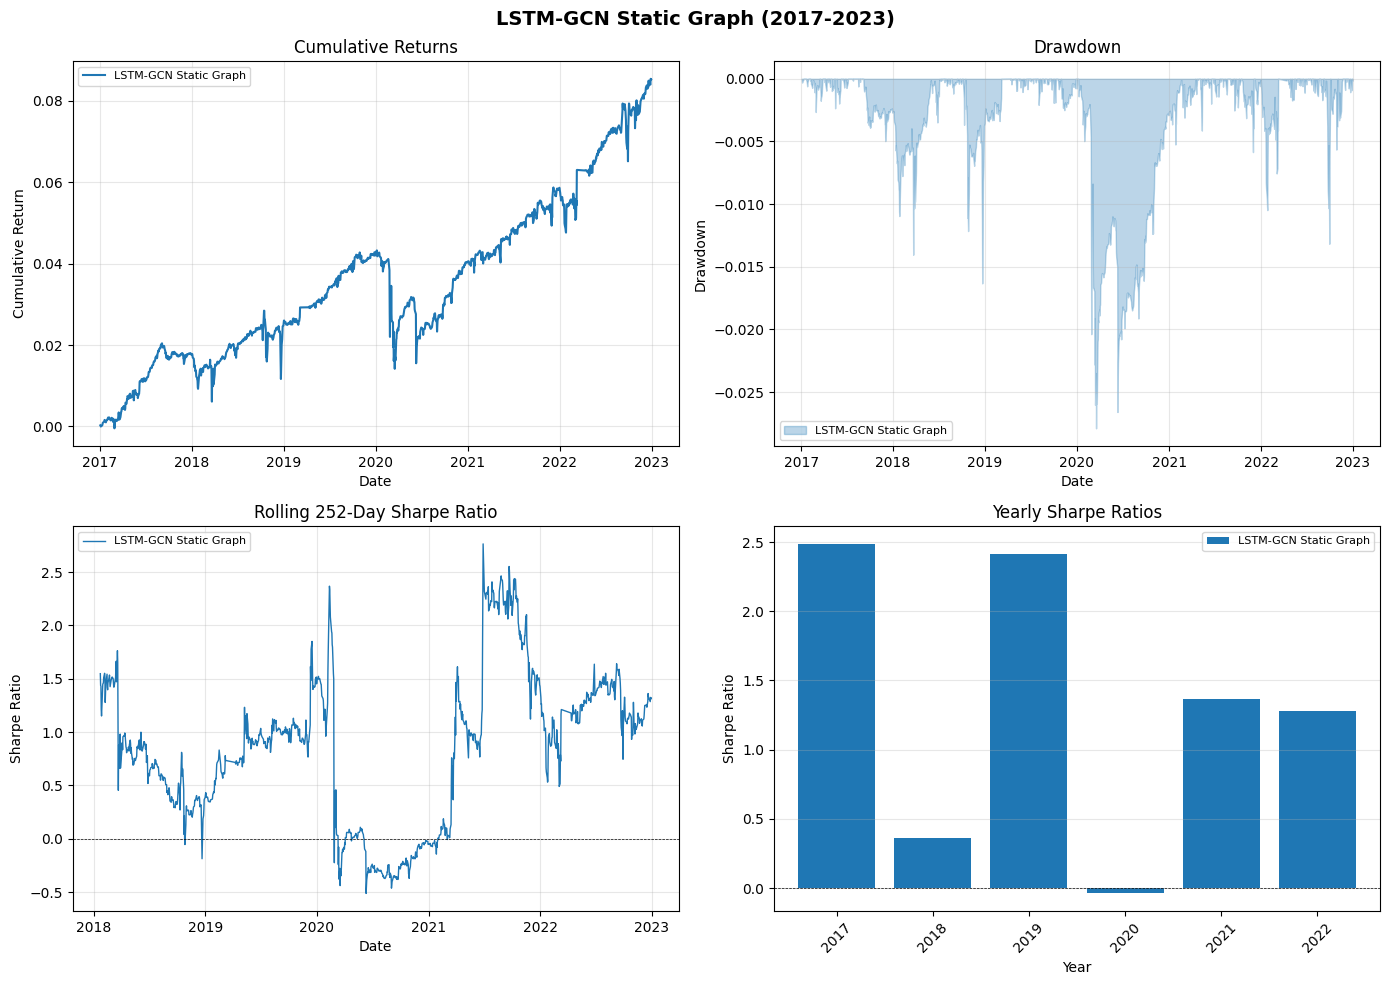

In [19]:
# Plot results
all_daily_returns = {'LSTM-GCN Static Graph': daily_returns}
plot_results(all_daily_returns, f"LSTM-GCN Static Graph ({TEST_START}-{TEST_END})")

## 9. Position Analysis

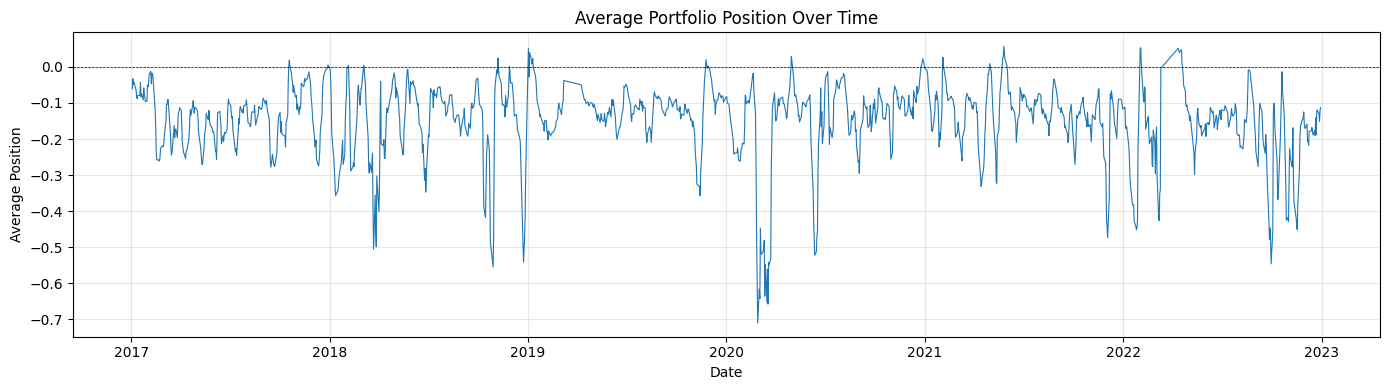

Average position: -0.1489
Position std: 0.1057


In [20]:
# Plot average position over time
avg_position = results_df.groupby('time')['position'].mean()

plt.figure(figsize=(14, 4))
plt.plot(avg_position.index, avg_position.values, linewidth=0.8)
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
plt.xlabel('Date')
plt.ylabel('Average Position')
plt.title('Average Portfolio Position Over Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average position: {avg_position.mean():.4f}")
print(f"Position std: {avg_position.std():.4f}")

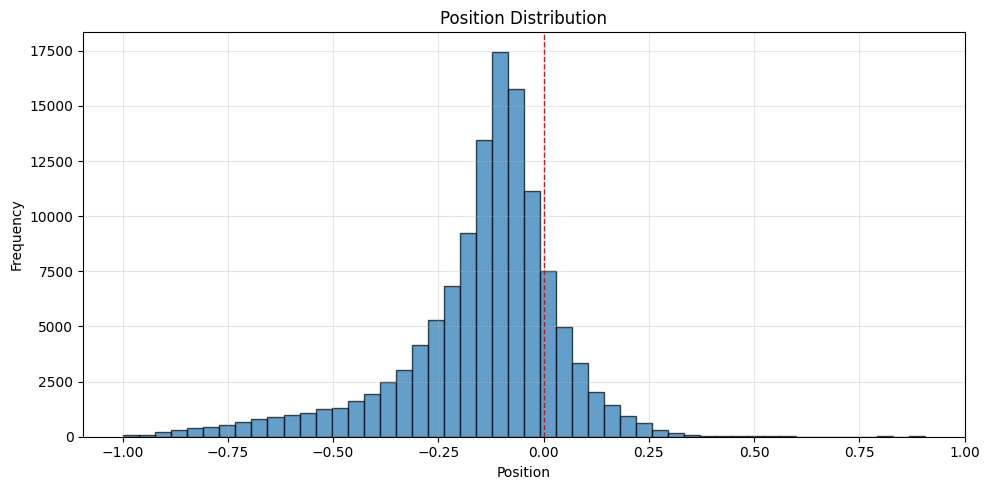

In [21]:
# Position distribution
plt.figure(figsize=(10, 5))
plt.hist(results_df['position'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Position')
plt.ylabel('Frequency')
plt.title('Position Distribution')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Save Results

In [22]:
# Create results directory (includes model version)
if GRAPH_TYPE == "cvx":
    results_dir = f"results/lstm_gcn_static_{MODEL_VERSION}_cvx_{ALPHA}_{BETA}/{TEST_START}-{TEST_END}"
elif GRAPH_TYPE == "pearson":
    results_dir = f"results/lstm_gcn_static_{MODEL_VERSION}_pearson_{TAU}/{TEST_START}-{TEST_END}"
elif GRAPH_TYPE == "straddle_pearson":
    norm_str = "norm" if NORMALIZE_ADJACENCY else "unnorm"
    train_str = "trainonly" if USE_TRAINING_DATA_ONLY else "alldata"
    results_dir = f"results/lstm_gcn_static_{MODEL_VERSION}_straddle_{TAU}_{norm_str}_{train_str}/{TEST_START}-{TEST_END}"
elif GRAPH_TYPE == "equity_pearson":
    norm_str = "norm" if NORMALIZE_ADJACENCY else "unnorm"
    train_str = "trainonly" if USE_TRAINING_DATA_ONLY else "alldata"
    results_dir = f"results/lstm_gcn_static_{MODEL_VERSION}_equity_{TAU}_{norm_str}_{train_str}/{TEST_START}-{TEST_END}"

os.makedirs(results_dir, exist_ok=True)

# Save captured returns
results_df.to_csv(os.path.join(results_dir, "captured_returns_sw.csv"), index=False)

# Save metrics
metrics_df = pd.DataFrame([metrics_raw])
metrics_df.to_csv(os.path.join(results_dir, "metrics_raw.csv"), index=False)

metrics_norm_df = pd.DataFrame([metrics_norm])
metrics_norm_df.to_csv(os.path.join(results_dir, "metrics_vol_normalized.csv"), index=False)

# Save yearly Sharpes
yearly_df = pd.DataFrame(yearly_sharpes.items(), columns=['Year', 'Sharpe'])
yearly_df.to_csv(os.path.join(results_dir, "yearly_sharpes.csv"), index=False)

print(f"Results saved to: {results_dir}")

Results saved to: results/lstm_gcn_static_v2_equity_0.5_norm_trainonly/2017-2023


## 11. Summary

In [ ]:
print("="*60)
print("EXPERIMENT SUMMARY")
print("="*60)
print(f"\nModel: LSTM-GCN with Static Graph ({MODEL_VERSION})")
if MODEL_VERSION == "v2":
    print("  Architecture: Original (residual connection, GCN→16→Dense→1)")
elif MODEL_VERSION == "v3":
    print("  Architecture: Paper-faithful (no residual, GCN→1)")
print(f"\nGraph Configuration:")
print(f"  Type: {GRAPH_TYPE}")
if GRAPH_TYPE == "cvx":
    print(f"  Alpha: {ALPHA}, Beta: {BETA}")
elif GRAPH_TYPE == "pearson":
    print(f"  Threshold (equity-based): {TAU}")
elif GRAPH_TYPE == "straddle_pearson":
    print(f"  Threshold (straddle-based): {TAU}")
    print(f"  Use training data only: {USE_TRAINING_DATA_ONLY}")
    print(f"  Normalize adjacency: {NORMALIZE_ADJACENCY}")
elif GRAPH_TYPE == "equity_pearson":
    print(f"  Threshold (equity log returns): {TAU}")
    print(f"  Use training data only: {USE_TRAINING_DATA_ONLY}")
    print(f"  Normalize adjacency: {NORMALIZE_ADJACENCY}")
print(f"\nModel Hyperparameters:")
print(f"  Hidden layer size: {HIDDEN_LAYER_SIZE}")
print(f"  GCN units: {GCN_UNITS}")
print(f"  Dropout: {DROPOUT_RATE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  GCN layers: {NUM_GCN_LAYERS}")
print(f"\nTraining Period: {TRAIN_START} - {TEST_START}")
print(f"Test Period:     {TEST_START} - {TEST_END}")
print(f"\nPerformance (Raw):")
print(f"  Sharpe Ratio: {metrics_raw['Sharpe']:.3f}")
print(f"  Annual Return: {metrics_raw['E[Ret.]']:.2%}")
print(f"  Annual Volatility: {metrics_raw['Vol.']:.2%}")
print(f"  Sortino Ratio: {metrics_raw['Sortino']:.3f}")
print(f"  Max Drawdown: {metrics_raw['Max DD']:.2%}")

EXPERIMENT SUMMARY

Model: LSTM-GCN with Static Graph (v2)
  Architecture: Original (residual connection, GCN→16→Dense→1)

Graph Configuration:
  Type: equity_pearson
  Threshold (equity log returns): 0.5
  Use training data only: True
  Normalize adjacency: True

Model Hyperparameters:
  Hidden layer size: 10
  GCN units: 16
  Dropout: 0.4
  Learning rate: 0.001
  GCN layers: 2

Training Period: 2011 - 2017
Test Period:     2017 - 2023

Performance (Raw):
  Sharpe Ratio: 0.800
  Annual Return: 1.48%
  Annual Volatility: 1.86%
  Sortino Ratio: 1.140
  Max Drawdown: 2.79%


In [24]:
from gml.experiment_utils import save_experiment_results

EXPERIMENT_NAME = "2_GCN_static"

if 'google.colab' in str(get_ipython()):
    RESULTS_BASE = "/content/drive/MyDrive/FINAL_RESULTS"
else:
    RESULTS_BASE = "FINAL_RESULTS"

test_dates_arr = pd.to_datetime(test_data['date'][:, 0, -1, 0])

hyperparams = {
    "model_type": "GCN_static",
    "hidden_layer_size": HIDDEN_LAYER_SIZE,
    "gcn_units": GCN_UNITS,
    "num_gcn_layers": NUM_GCN_LAYERS,
    "dropout_rate": DROPOUT_RATE,
    "learning_rate": LEARNING_RATE,
    "max_gradient_norm": MAX_GRADIENT_NORM,
    "batch_size": BATCH_SIZE,
    "graph_type": GRAPH_TYPE,
    "tau": TAU,
    "total_time_steps": TOTAL_TIME_STEPS,
    "train_start": TRAIN_START,
    "test_start": TEST_START,
    "test_end": TEST_END,
}

save_experiment_results(
    experiment_name=EXPERIMENT_NAME,
    seed=40,
    predictions=predictions,
    results_df=results_df,
    daily_returns=daily_returns,
    metrics_raw=metrics_raw,
    metrics_norm=metrics_norm,
    yearly_sharpes=yearly_sharpes,
    training_history=history.history,
    hyperparams=hyperparams,
    test_dates=test_dates_arr.values,
    adjacency=adjacency,
    model=model,
    base_dir=RESULTS_BASE,
)

Results saved to: /content/drive/MyDrive/FINAL_RESULTS/2_GCN_static/seed_40
Saved 11 files:
  captured_returns_sw.csv (8.1 MB)
  yearly_sharpes.csv (156 B)
  metrics_vol_normalized.csv (249 B)
  daily_returns.csv (46.0 KB)
  training_history.json (10.2 KB)
  metrics_raw.csv (239 B)
  predictions.npy (9.4 MB)
  hyperparams.json (338 B)
  test_dates.npy (11.1 KB)
  adjacency.npy (60.6 KB)
  model_weights/weights.weights.h5 (235.9 KB)
